Data Loaded Successfully


/tmp/ipykernel_57/2609031639.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), n_samples), random_state=42))



Top Features:
['ack_flag_number', 'Max', 'fin_count', 'Number', 'Protocol_Type', 'Tot_size', 'syn_count', 'psh_flag_number', 'Tot_sum', 'Duration', 'Min', 'rst_count', 'Header_Length', 'Rate', 'IAT']

Accuracy:
0.9764953664700927

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1500
           1       1.00      1.00      1.00      1500
           2       1.00      1.00      1.00      1500
           3       1.00      1.00      1.00      1500
           4       1.00      1.00      1.00      1500
           5       1.00      1.00      1.00      1500
           6       1.00      1.00      1.00      1500
           7       1.00      1.00      1.00      1500
           8       1.00      1.00      1.00      1500
           9       1.00      1.00      1.00      1500
          10       1.00      1.00      1.00      1500
          11       1.00      1.00      1.00      1500
          12       0.94      0.97      0.9

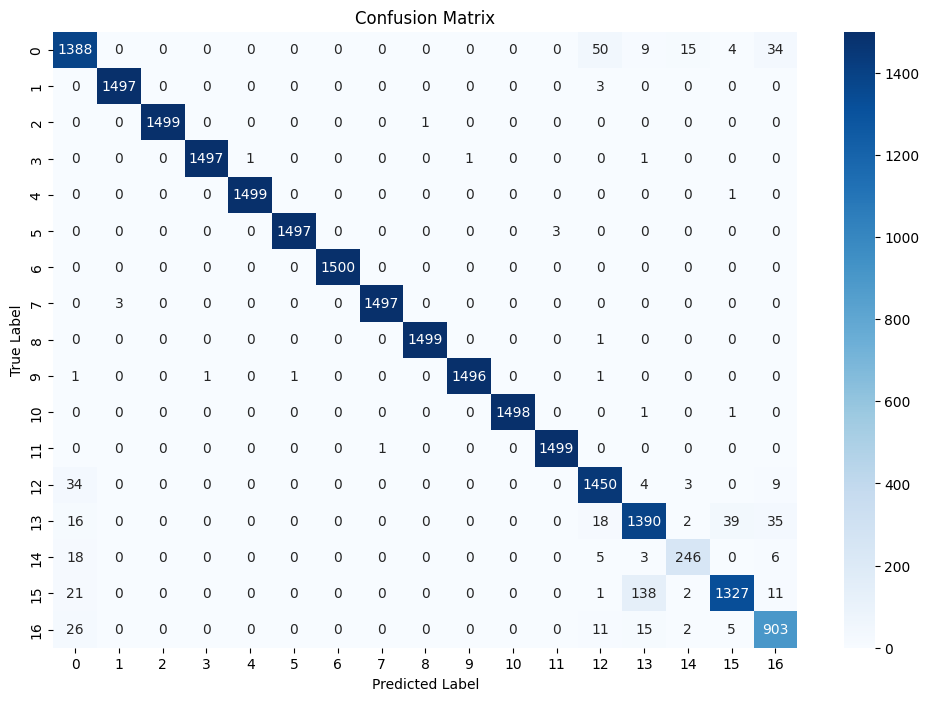

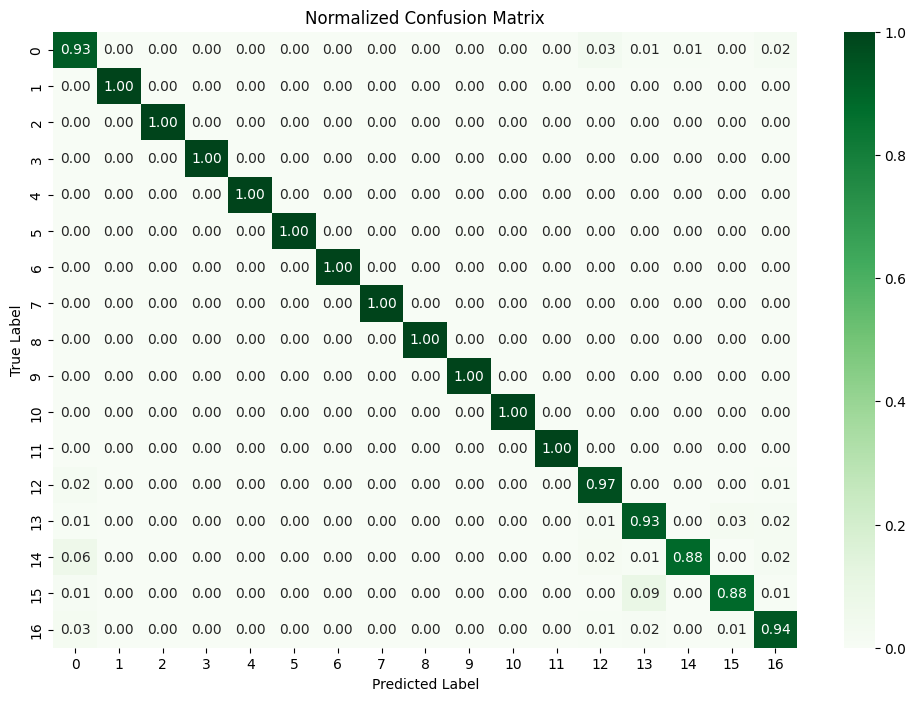


FINAL ZERO-DAY RESULT
Total Samples       : 5000
Detected Attacks    : 4969
Detection Rate (%)  : 99.38

Model Saved Successfully


In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



train_df = pd.read_csv('/kaggle/input/datasets/shahdsameh123/shahd-s/train_iomt.csv')
test_df = pd.read_csv('/kaggle/input/datasets/shahdsameh123/shahd-s/test_iomt.csv')

df = pd.concat([train_df, test_df]).dropna()
df.columns = df.columns.str.replace(' ', '_')

print("Data Loaded Successfully")


le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


target_col = 'label'



n_samples = 5000

df_balanced = (
    df.groupby(target_col, group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), n_samples), random_state=42))
    .reset_index(drop=True)
)



zero_day_label = 17

df_known = df_balanced[df_balanced[target_col] != zero_day_label]
df_zero = df_balanced[df_balanced[target_col] == zero_day_label]



X = df_known.drop(columns=[target_col])
y = df_known[target_col]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)



selector = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbose=-1
)

selector.fit(X_train, y_train)

importances = selector.feature_importances_

top_idx = np.argsort(importances)[-15:]
top_features = X.columns[top_idx]

X_train = X_train[top_features]
X_test = X_test[top_features]
X_zero = df_zero[top_features]

print("\nTop Features:")
print(list(top_features))



rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    random_state=42
)

xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric='mlogloss',
        random_state=42
    ))
])

lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=50,
    random_state=42,
    verbose=-1
)



vote = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    voting='soft'
)

vote.fit(X_train, y_train)



y_pred = vote.predict(X_test)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



labels = sorted(y.unique())

cm_norm = confusion_matrix(
    y_test,
    y_pred,
    normalize='true'
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



iso = IsolationForest(
    contamination=0.25,
    n_estimators=200,
    random_state=42
)

iso.fit(X_train)


vote_preds = vote.predict(X_zero)
iso_preds = iso.predict(X_zero)

final_zero_preds = []

for v, i in zip(vote_preds, iso_preds):

    if i == -1:
        final_zero_preds.append(1)

    else:
        final_zero_preds.append(0 if v == 0 else 1)

final_zero_preds = np.array(final_zero_preds)

detected = final_zero_preds.sum()
total = len(final_zero_preds)

detection_rate = (detected / total) * 100


print("\n" + "=" * 40)
print("FINAL ZERO-DAY RESULT")
print("=" * 40)

print(f"Total Samples       : {total}")
print(f"Detected Attacks    : {detected}")
print(f"Detection Rate (%)  : {detection_rate:.2f}")



joblib.dump(vote, "FINAL_MODEL.pkl")

print("\nModel Saved Successfully")